# **Modelos secuenciales: LSTM inter-época e híbrido CNN1D $\to$ BiLSTM**

Este cuaderno entrena y compara los **dos modelos secuenciales** del proyecto con **una sola función** (`src.lstm.train`) y el **mismo split por sujeto**, para que sus métricas sean directamente comparables:

1. **LSTM tabular** (`hybrid=False`): una BiLSTM many-to-many sobre la secuencia de **features handcrafted** por época (`epoch_features.csv`). El encoder intra-época es `IdentityEncoder` (pasa las features tal cual). Modela la **dinámica inter-época**.
2. **Híbrido CNN1D $\to$ BiLSTM** (`hybrid=True`): una **CNN 1D** (`CNNEpochEncoder`) resume la **señal cruda** de cada época (`sequences/*.npz`, `[150, 4]`) en un vector, y la BiLSTM lee esa secuencia. Se entrena **end-to-end** (una sola loss ajusta CNN y LSTM juntas). Combina morfología **intra-época** y dinámica **inter-época**.

## Arquitectura común
$$\text{época}[\dots] \;\xrightarrow{\text{encoder}}\; [T, F_{enc}] \;\xrightarrow{\text{BiLSTM (2 capas)}}\; \text{Dropout} \to \text{Linear} \to \text{logits}[T, 5]$$

- **encoder**: `IdentityEncoder` (tabular, $F_{enc}=122$) o `CNNEpochEncoder` (híbrido, $F_{enc}=128$). Es el único punto que cambia entre modos.
- **BiLSTM**: `hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True`. Lee la noche hacia adelante y hacia atrás (sleep staging offline → sin restricción de causalidad).
- **Padding + packing**: las noches tienen largo variable; `collate_nights` paddea al máximo del batch (features con 0.0, labels con `UNKNOWN=5`) y `pack_padded_sequence` hace que la LSTM ignore el relleno. La loss usa `ignore_index=UNKNOWN` (Unknown + padding fuera de la loss y de las métricas).
- **Loss**: `CrossEntropyLoss` con **pesos de clase** inversos a la frecuencia (desbalance N2 ≫ N1) + **gradient clipping**.

## Split y comparabilidad
El split es **por sujeto** (`partition_subjects`, sujetos disjuntos train/val/test), con la **misma seed y fracciones** para los dos modelos $\implies$ **exactamente los mismos sujetos** en cada partición. Así la diferencia de Kappa entre LSTM e híbrido refleja el modelo, no la partición.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, glob
sys.path.append("..")

# import temprano de torch._dynamo: evita un fallo de sympy con kernel de estado sucio.
import torch
import torch._dynamo  # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.lstm import ConfigLSTM, train, evaluate, plot_history, STAGE_NAMES
from src.sequence_data import build_night_sequences

c:\Users\agust\anaconda3\envs\pf_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datos (se generan solo si faltan)

- **`epoch_features.csv`** (modo tabular): lo produce `baseline.ipynb` (feature extraction). Si no existe, se genera acá.
- **`sequences/*.npz`** (modo híbrido): señal cruda por noche + `night_id`.

Ambos derivan de los mismos pacientes, así que el split por sujeto coincide entre modos.

In [2]:
FEATURES = "../data_extraction/epoch_features.csv"
if os.path.exists(FEATURES):
    print(f"{FEATURES} ya existe; se omite la extracción.")
else:
    from src.feature_extraction import feature_extraction
    feature_extraction()

SEQ_DIR = "../data_extraction/sequences"
if glob.glob(os.path.join(SEQ_DIR, "*.npz")):
    print(f"{SEQ_DIR} ya tiene datos; se omite el procesamiento.")
else:
    build_night_sequences(output_dir=SEQ_DIR)

../data_extraction/epoch_features.csv ya existe; se omite la extracción.
../data_extraction/sequences ya tiene datos; se omite el procesamiento.


## 2. Configuración y split compartido

Dos `ConfigLSTM` que difieren solo en el modo (`hybrid`) y el checkpoint. La **misma seed** garantiza el **mismo split por sujeto** para los dos. `TRAIN_NEW` es la constante universal entrenar-de-cero / usar-guardado.

In [3]:
TRAIN_NEW = True  # True: entrena de cero y sobreescribe el checkpoint; False: usa el .pt guardado

# configuraciones default
cfg_lstm = ConfigLSTM(hybrid=False, ckpt_path="../models/best_lstm.pt",
                      epochs=60, patience=10)
cfg_hyb = ConfigLSTM(hybrid=True,  ckpt_path="../models/best_hybrid.pt",
                      hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True,
                      batch_size=8, lr=1e-3, epochs=120, patience=20, use_class_weights=True)

## 2.5 Búsqueda bayesiana de hiperparámetros (Optuna)

Antes de entrenar los modelos "finales" buscamos buenos hiperparámetros con **búsqueda bayesiana** en lugar de probar a mano o hacer *grid search*.

**¿Qué es?** El *grid/random search* prueba configuraciones **a ciegas**. La búsqueda bayesiana construye un **modelo probabilístico** de la relación *hiperparámetros $\to$ métrica* y, a partir de los trials ya evaluados, propone la **siguiente configuración más prometedora** (equilibrando explorar zonas nuevas y explotar las que rindieron bien). Así llega a buenas configuraciones con **muchos menos entrenamientos**.

**Cómo lo hacemos (`src/tuning.py`, con [Optuna](https://optuna.org/)):**
- El sampler **TPE** (*Tree-structured Parzen Estimator*) implementa la parte bayesiana.
- **Objetivo a maximizar: el Cohen's Kappa del set de _validación_**. Se toma el kappa del mejor epoch, igual criterio con que `train` guarda el checkpoint.
- Espacio de búsqueda (`default_space`): `hidden_size`, `num_layers`, `dropout`, `lr`, `weight_decay`, `batch_size` (+ `feature_dim` en el híbrido). El resto de la config (seed, fracciones del split, `hybrid`, paths) queda **fijo** ⇒ split por sujeto idéntico entre trials y entre modelos.
- **Se corren dos búsquedas independientes**, una por modelo.

**Costo y optimizaciones (clave en el híbrido).** El híbrido es mucho más pesado que el tabular: corre una CNN por época de cada noche (~24–27 s/epoch con `feature_dim=128`, más con 256), todo en GPU. Para que el search sea viable:
- **`search_epochs`**: cada trial entrena menos epochs que el entrenamiento final (acá 25 tabular / 15 híbrido). Basta para **rankear** configs; al ganador se lo re-entrena con todas las epochs vía `USE_BEST`.
- **MedianPruner**: corta un trial apenas su kappa de val cae por debajo de la mediana de los previos al mismo epoch. Los trials podados **no** se guardan en el CSV.
- **AMP (mixed precision)**: `train` usa `autocast`+`GradScaler` en GPU (flag `cfg.amp`, auto-on en cuda). Baja memoria; el extra de velocidad es modesto acá porque la LSTM casi no se acelera.

**Persistencia (para correr el search en varias instancias):** cada estudio se guarda en `models/searchs/<name>.db` (SQLite $\to$ **resume** donde quedó y el TPE aprovecha todo el historial) y en `models/searchs/<name>.csv`, un log legible con **toda la config** de cada trial + su `kappa/macro_f1/accuracy` de val. Cada corrida **agrega** sus trials nuevos (no reescribe) y deja el CSV **ordenado por kappa descendente**. `best_config(base_cfg, name)` levanta del CSV los mejores hiperparámetros sobre la config base (conservando `epochs`/paths de la base).

In [4]:
from src.tuning import run_search, best_config

RUN_SEARCH = True  # True: corre N_TRIALS de búsqueda bayesiana por modelo.
N_TRIALS = 5       # trials POR ejecución.

if RUN_SEARCH:
    run_search(cfg_lstm, name="lstm", n_trials=N_TRIALS, search_epochs=25)
    run_search(cfg_hyb, name="hybrid", n_trials=N_TRIALS, search_epochs=15)

[I 2026-07-07 19:12:54,367] Using an existing study with name 'lstm' instead of creating a new one.
Best trial: 3. Best value: 0.454721:  20%|██        | 1/5 [03:29<13:58, 209.53s/it]

[I 2026-07-07 19:16:24,099] Trial 15 pruned. 


Best trial: 16. Best value: 0.460216:  40%|████      | 2/5 [08:19<12:51, 257.11s/it]

[I 2026-07-07 19:21:14,524] Trial 16 finished with value: 0.460215653957751 and parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.2073912852388153, 'lr': 0.0008034772148815761, 'weight_decay': 0.00028195971523941747, 'batch_size': 4}. Best is trial 16 with value: 0.460215653957751.


Best trial: 16. Best value: 0.460216:  60%|██████    | 3/5 [13:23<09:16, 278.37s/it]

...

[I 2026-07-07 20:01:38,084] Trial 8 finished with value: 0.3034746939582389 and parameters: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.3703663165603608, 'lr': 0.0036835119466619884, 'weight_decay': 0.0003539178982628887, 'batch_size': 8, 'feature_dim': 256}. Best is trial 5 with value: 0.30977028271579243.


Best trial: 5. Best value: 0.30977:  80%|████████  | 4/5 [28:06<07:03, 423.26s/it]

[I 2026-07-07 20:03:49,592] Trial 9 pruned. 


Best trial: 5. Best value: 0.30977: 100%|██████████| 5/5 [44:51<00:00, 538.25s/it]


[I 2026-07-07 20:20:34,523] Trial 10 finished with value: 0.30977028271579243 and parameters: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.4366107897120125, 'lr': 0.0005811604803142423, 'weight_decay': 4.078835816332079e-05, 'batch_size': 8, 'feature_dim': 256}. Best is trial 5 with value: 0.30977028271579243.

[hybrid] mejor kappa de val: 0.3098 (trial 5)
  params: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.4366107897120125, 'lr': 0.0005811604803142423, 'weight_decay': 4.078835816332079e-05, 'batch_size': 8, 'feature_dim': 256}
  log: ..\models\searchs\hybrid.csv  |  storage: sqlite:///../models/searchs/hybrid.db


In [5]:
USE_BEST = True  # True: reemplaza los hiperparámetros de las configuraciones por los mejores del search
			     # False: utiliza hiperparámetros de las configuraciones default

if USE_BEST:
    cfg_lstm = best_config(cfg_lstm, "lstm")
    cfg_hyb = best_config(cfg_hyb, "hybrid")
    print("cfg_lstm ->", cfg_lstm)
    print("cfg_hyb  ->", cfg_hyb)

cfg_lstm -> ConfigLSTM(hybrid=False, features_path='../data_extraction/epoch_features.csv', sequences_dir='../data_extraction/sequences', feature_dim=128, hidden_size=128, num_layers=3, dropout=0.3416493362665036, bidirectional=True, batch_size=4, lr=0.0018273545014266, weight_decay=0.0001339959719863, epochs=60, grad_clip=5.0, use_class_weights=True, amp=None, patience=10, val_frac=0.15, test_frac=0.15, seed=36631, device='cuda', ckpt_path='../models/best_lstm.pt', feature_cols=None, input_size=None)
cfg_hyb  -> ConfigLSTM(hybrid=True, features_path='../data_extraction/epoch_features.csv', sequences_dir='../data_extraction/sequences', feature_dim=256, hidden_size=128, num_layers=3, dropout=0.4366107897120125, bidirectional=True, batch_size=8, lr=0.0005811604803142, weight_decay=4.078835816332079e-05, epochs=120, grad_clip=5.0, use_class_weights=True, amp=None, patience=20, val_frac=0.15, test_frac=0.15, seed=36631, device='cuda', ckpt_path='../models/best_hybrid.pt', feature_cols=None

## 3. LSTM tabular (inter-época)

BiLSTM sobre las 122 features handcrafted ([epoch_features.csv](data_extraction/epoch_features.csv)).

In [6]:
if TRAIN_NEW or not os.path.exists(cfg_lstm.ckpt_path):
    model_lstm, hist_lstm, test_lstm = train(cfg_lstm)
else:
    model_lstm, test_lstm = evaluate(cfg_lstm)
    hist_lstm = None

Early Stop (LSTM) - epoch 25 (mejor 0.4654 @ 15):  40%|████      | 24/60 [07:09<10:44, 17.91s/epoch, train_loss=0.7582, val_loss=1.1217, val_kappa=0.4491, best=0.4654]



TEST (LSTM) — mejor ckpt (val kappa 0.4654, epoch 15):
  kappa 0.4503 | macroF1 0.5582 | acc 0.5727
  4-clases: kappa 0.4754 | macroF1 0.6417 | acc 0.6282


## 4. Híbrido CNN1D $\to$ BiLSTM

La misma `train`, con `hybrid=True`: el `CNNEpochEncoder` (GroupNorm, robusto al padding) resume cada época de señal cruda `[150, 4]` en 128 features y la BiLSTM lee la secuencia. Más lento (la CNN corre sobre todas las épocas de cada noche); conviene GPU.

In [7]:
if TRAIN_NEW or not os.path.exists(cfg_hyb.ckpt_path):
    model_hyb, hist_hyb, test_hyb = train(cfg_hyb)
else:
    model_hyb, test_hyb = evaluate(cfg_hyb)
    hist_hyb = None

Early Stop (Hybrid) - epoch 102 (mejor 0.4033 @ 82):  84%|████████▍ | 101/120 [1:15:57<14:17, 45.12s/epoch, train_loss=0.6509, val_loss=1.4437, val_kappa=0.3621, best=0.4033]



TEST (Hybrid) — mejor ckpt (val kappa 0.4033, epoch 82):
  kappa 0.3442 | macroF1 0.4696 | acc 0.4756
  4-clases: kappa 0.3672 | macroF1 0.5492 | acc 0.5497


## 5. Curvas de entrenamiento (train vs validación)

Para cada modelo: (izq) loss de **train vs validación** por epoch - si divergen, sobreajuste; (der) métricas de **validación** (kappa/macro-F1/accuracy) que muestran en qué epoch quedó el mejor checkpoint.

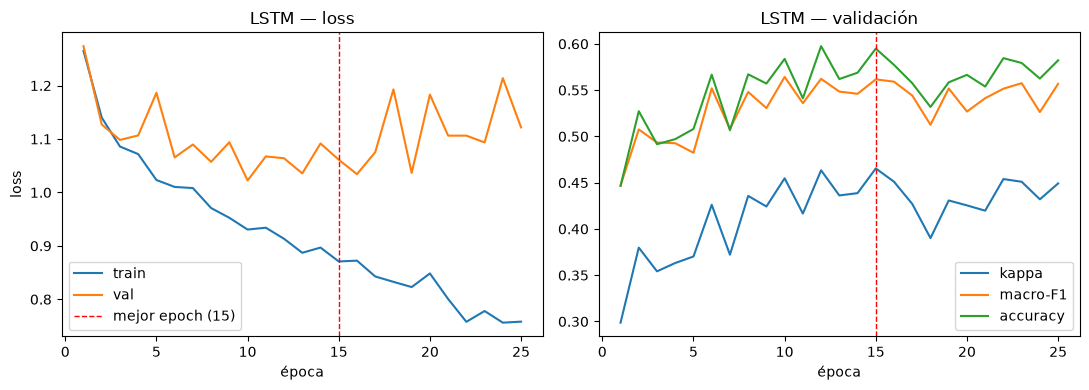

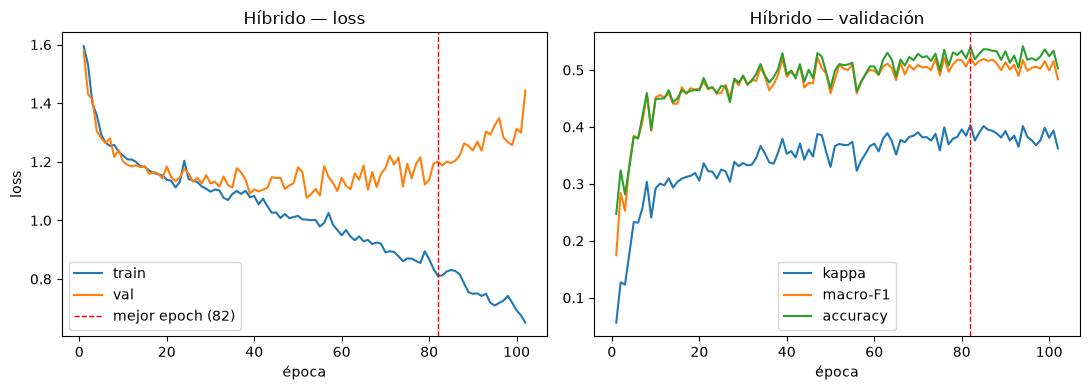

In [8]:
for name, hist in [('LSTM', hist_lstm), ('Híbrido', hist_hyb)]:
    if hist is None:
        print(f"{name}: sin history (TRAIN_NEW=False); se omiten las curvas.")
    else:
        plot_history(hist, title=name)
        plt.tight_layout(); plt.show()

## 6. Comparación en test (mismo split)

Métricas de test de los dos modelos, calculadas sobre el **mismo test set por sujeto**: Cohen's Kappa (principal), macro-F1 y accuracy, en 5 clases y en la vista colapsada a 4 (Wake / Light=N1+N2 / Deep=N3 / REM). Más la matriz de confusión de cada uno.

In [9]:
rows = []
for name, tm in [('LSTM tabular', test_lstm), ('Híbrido', test_hyb)]:
    rows.append({'modelo': name, 'kappa': tm['kappa'], 'macro_f1': tm['macro_f1'],
                 'accuracy': tm['accuracy'], 'kappa_4': tm['kappa_4'],
                 'macro_f1_4': tm['macro_f1_4'], 'accuracy_4': tm['accuracy_4']})
summary = pd.DataFrame(rows).set_index('modelo').round(4)
print("Test (mismo split por sujeto, vs Expert):")
print(summary.to_string())

for name, tm in [('LSTM tabular', test_lstm), ('Híbrido', test_hyb)]:
    print(f"\nMatriz de confusión — {name} (5 clases):")
    print(pd.DataFrame(tm['confusion'], index=STAGE_NAMES, columns=STAGE_NAMES))

Test (mismo split por sujeto, vs Expert):
               kappa  macro_f1  accuracy  kappa_4  macro_f1_4  accuracy_4
modelo                                                                   
LSTM tabular  0.4503    0.5582    0.5727   0.4754      0.6417      0.6282
Híbrido       0.3442    0.4696    0.4756   0.3672      0.5492      0.5497

Matriz de confusión — LSTM tabular (5 clases):
      Wake    N1    N2    N3   REM
Wake  1921   655   128   201   456
N1     269   945   229   106  1227
N2     202  1408  4811  1516  3544
N3      15   185   601  4294   559
REM     70   461   589   183  4919

Matriz de confusión — Híbrido (5 clases):
      Wake    N1    N2    N3   REM
Wake  2048   718   110   212   273
N1     536  1175   245   161   659
N2    1116  1941  3408  1962  3054
N3     599   396   453  3920   286
REM    240  1233   805   467  3477


## 7. Overview de una noche con las predicciones

Como el `night_overview` del EDA, pero agregando debajo de las señales los **hipnogramas** de Expert, Dreem y las predicciones de **ambos modelos** (LSTM tabular e híbrido), alineados por índice de época. Permite ver *dónde* acierta o falla cada modelo a lo largo de la noche (típicamente en las transiciones y en N1).

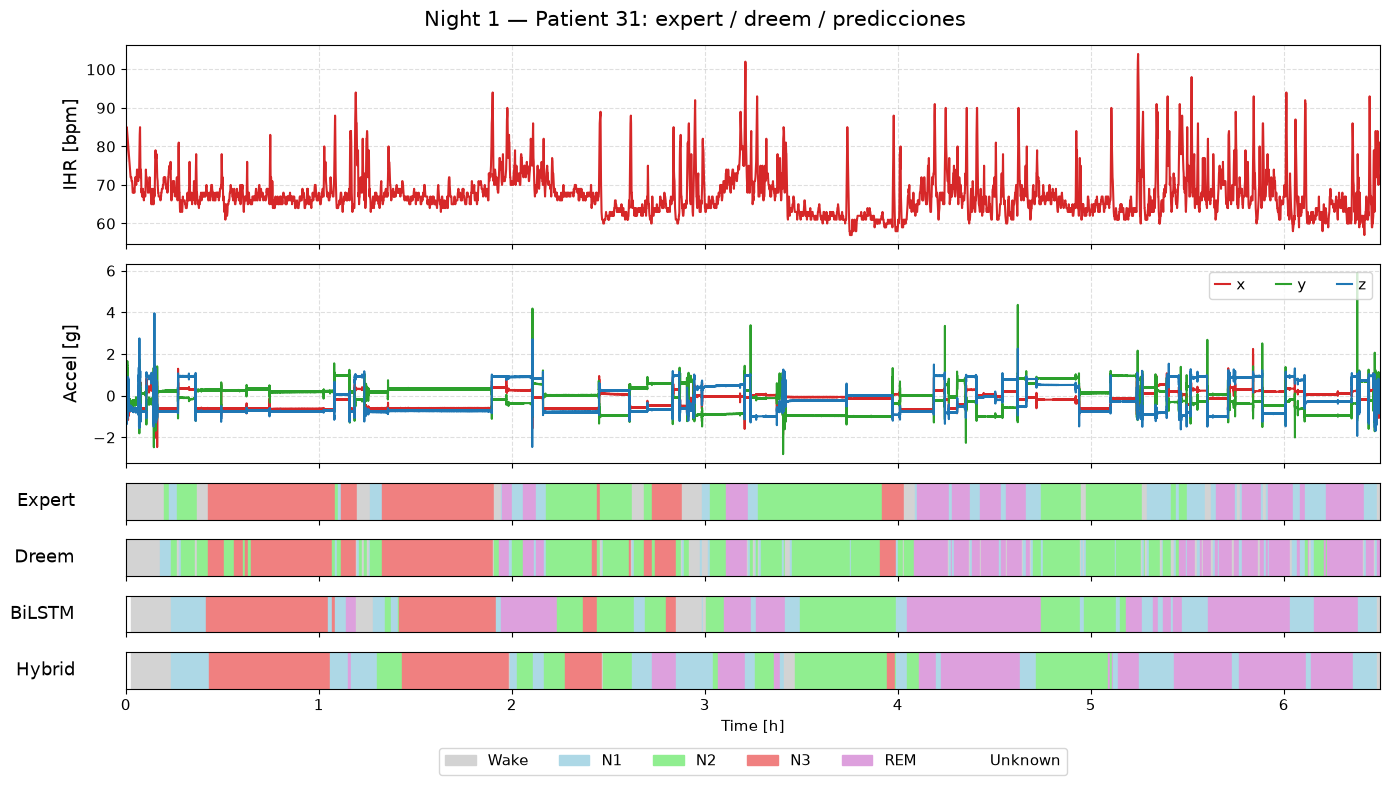

In [10]:
from src.plots import night_prediction_overview
from src.lstm import predict_night

# una noche del test set (sujetos de test del split compartido, guardados en el checkpoint)
ckpt = torch.load(cfg_lstm.ckpt_path, map_location='cpu', weights_only=False)
subject = sorted(ckpt['subj']['test'])[1]
night = int(pd.read_csv(cfg_lstm.features_path).query('subject == @subject')['night'].min())

preds = {'BiLSTM': predict_night(model_lstm, cfg_lstm, subject, night)}
try:
    preds['Hybrid'] = predict_night(model_hyb, cfg_hyb, subject, night)
except KeyError as e:
    print(f"fila híbrido omitida: {e}")

night_prediction_overview(subject, night, preds)